In [1]:
import subprocess, sys
pkgs = [
    "tab-transformer-pytorch", "torch", "scikit-learn",
    "pandas", "numpy", "tqdm", "matplotlib", "seaborn", ]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", p, "-q"], check=False)
print("Cai dat hoan tat")

Cai dat hoan tat


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, accuracy_score, confusion_matrix,
    cohen_kappa_score, matthews_corrcoef, roc_curve,
)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from IPython.display import display, HTML, clear_output

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch      :", torch.__version__)
print("TabTransformer imported OK")
print("Device       :", DEVICE)

PyTorch      : 2.9.0+cu126
TabTransformer imported OK
Device       : cuda


In [2]:
CSV_PATH  = "/kaggle/input/datasets/iqsnguyn/lancuoidibennhau/Denguediseasesdataset1003.csv_clean.csv"   
LABEL_COL = "Final Output"     

N_FOLDS      = 5
EPOCHS       = 60
BATCH_SIZE   = 32
LR           = 1e-4
WEIGHT_DECAY = 1e-5
SEED         = 42

# TabTransformer hyperparameters
DIM        = 32    
DEPTH      = 6     
HEADS      = 8     
ATTN_DROP  = 0.1
FF_DROP    = 0.1

torch.manual_seed(SEED)
np.random.seed(SEED)
print("Config loaded | device =", DEVICE)

Config loaded | device = cuda


In [3]:
df = pd.read_csv(CSV_PATH)
assert LABEL_COL in df.columns, "Khong tim thay cot nhan: " + LABEL_COL

raw_label   = df[LABEL_COL]
unique_vals = sorted(raw_label.dropna().astype(str).unique())
print("Gia tri nhan:", unique_vals)
try:
    df[LABEL_COL] = raw_label.astype(float).astype(int)
    print("Nhan kieu so — dung truc tiep.")
except (ValueError, TypeError):
    label_map = {v: i for i, v in enumerate(unique_vals)}
    print("Nhan kieu text. Auto-map:", label_map)
    print(">>> Neu map sai, sua dong label_map roi chay lai.")
    # label_map = {"negative": 0, "positive": 1}  # override neu can
    df[LABEL_COL] = raw_label.map(label_map).astype(int)

assert df[LABEL_COL].isin([0, 1]).all(), "Nhan chua duoc map ve 0/1!"

n_pos = int(df[LABEL_COL].sum())
n_neg = len(df) - n_pos

info_html = (
    "<div style='background:#1e1e2e;color:#cdd6f4;padding:16px 24px;"
    "border-radius:10px;font-family:monospace;line-height:2.2'>"
    "<b style='color:#89b4fa;font-size:1.1em'>Thong tin du lieu</b><br>"
    "Tong mau   : <b style='color:#a6e3a1'>" + str(len(df)) + "</b><br>"
    "So cot     : <b style='color:#a6e3a1'>" + str(df.shape[1]) + "</b><br>"
    "Duong tinh (1) : <b style='color:#f38ba8'>" + str(n_pos) + "</b>"
    " | Am tinh (0) : <b style='color:#89dceb'>" + str(n_neg) + "</b>"
    " | Ti le : <b style='color:#fab387'>" + str(round(n_neg/max(n_pos,1),2)) + ":1</b>"
    "</div>"
)
display(HTML(info_html))
print("\nCac cot va dtype:")
print(df.drop(columns=[LABEL_COL]).dtypes.to_string())
df.head()

Gia tri nhan: ['0.0', '1.0']
Nhan kieu so — dung truc tiep.



Cac cot va dtype:
Age                     int64
Sex                    object
Haemoglobin           float64
WBC Count             float64
Differential Count      int64
RBC PANEL               int64
Platelet Count        float64
PDW                   float64


,Age,Sex,Haemoglobin,WBC Count,Differential Count,RBC PANEL,Platelet Count,PDW,Final Output
0,43,Male,12.6,2200.0,1,1,62000.0,11.0,1
1,45,Male,13.2,3000.0,0,1,17000.0,17.0,1
2,50,Female,11.0,3300.0,1,1,19000.0,16.3,1
3,57,Female,11.9,3500.0,1,0,29000.0,14.0,1
4,51,Female,13.0,3100.0,0,1,30000.0,14.5,1


In [4]:
CAT_COLS = ['Sex', 'Differential Count']
NUM_COLS = ['Haemoglobin', 'Age', 'WBC Count', 'Platelet Count', 'PDW' ]


missing_cat = [c for c in CAT_COLS if c not in df.columns]
missing_num = [c for c in NUM_COLS if c not in df.columns]
if missing_cat:
    print("CANH BAO — cot categorical KHONG tim thay trong CSV:", missing_cat)
if missing_num:
    print("CANH BAO — cot numerical KHONG tim thay trong CSV:", missing_num)

assert len(CAT_COLS) + len(NUM_COLS) > 0, "Phai chon it nhat 1 feature!"
assert len(CAT_COLS) > 0 or True, "" 

# Loại bỏ cột bị thiếu
CAT_COLS = [c for c in CAT_COLS if c in df.columns]
NUM_COLS = [c for c in NUM_COLS if c in df.columns]

print("Categorical (" + str(len(CAT_COLS)) + "):", CAT_COLS if CAT_COLS else "khong co")
print("Numerical   (" + str(len(NUM_COLS)) + "):", NUM_COLS)

if CAT_COLS:
    print()
    print("Gia tri unique cua tung cot categorical:")
    for col in CAT_COLS:
        print("  ", col, "->", sorted(df[col].astype(str).unique()))

if not CAT_COLS:
    print()
    print("LUU Y: Khong co categorical cols — TabTransformer se dung MLP thuan.")
    print("       Neu muon dung dung Transformer, hay them cot categorical.")

Categorical (2): ['Sex', 'Differential Count']
Numerical   (5): ['Haemoglobin', 'Age', 'WBC Count', 'Platelet Count', 'PDW']

Gia tri unique cua tung cot categorical:
   Sex -> ['Child', 'Female', 'Male']
   Differential Count -> ['0', '1']


In [5]:
def compute_metrics(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    ppv  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    npv  = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    return dict(
        AUROC       = roc_auc_score(y_true, y_prob),
        Accuracy    = accuracy_score(y_true, y_pred),
        Sensitivity = sens,
        Specificity = spec,
        PPV         = ppv,
        NPV         = npv,
        Kappa       = cohen_kappa_score(y_true, y_pred),
        Threshold   = threshold,
        TP=int(tp), TN=int(tn), FP=int(fp), FN=int(fn),
    )


def tune_threshold_mcc(y_true, y_prob, n=200):
    best_mcc, best_thr = -2.0, 0.5
    for thr in np.linspace(0.01, 0.99, n):
        mcc = matthews_corrcoef(y_true, (y_prob >= thr).astype(int))
        if mcc > best_mcc:
            best_mcc, best_thr = mcc, thr
    return float(best_thr)


def encode_fold(df_tr, df_val, cat_cols, num_cols, label_col):
    df_tr  = df_tr.copy()
    df_val = df_val.copy()

    cat_dims     = []
    cat_encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df_tr[col]  = le.fit_transform(df_tr[col].astype(str))
        known = set(le.classes_)
        df_val[col] = df_val[col].astype(str).apply(
            lambda x: x if x in known else le.classes_[0]
        )
        df_val[col] = le.transform(df_val[col])
        cat_dims.append(int(df_tr[col].max()) + 1)
        cat_encoders[col] = le

    scaler = None
    if num_cols:
        scaler = StandardScaler()
        arr_tr  = scaler.fit_transform(df_tr[num_cols].values.astype("float32"))
        arr_val = scaler.transform(df_val[num_cols].values.astype("float32"))
        x_num_tr  = torch.tensor(arr_tr,  dtype=torch.float32)
        x_num_val = torch.tensor(arr_val, dtype=torch.float32)
    else:
        x_num_tr  = torch.zeros(len(df_tr),  0, dtype=torch.float32)
        x_num_val = torch.zeros(len(df_val), 0, dtype=torch.float32)

    cat_tr_arr  = df_tr[cat_cols].values.reshape(len(df_tr),  len(cat_cols))
    cat_val_arr = df_val[cat_cols].values.reshape(len(df_val), len(cat_cols))
    x_cat_tr  = torch.tensor(cat_tr_arr,  dtype=torch.long)
    x_cat_val = torch.tensor(cat_val_arr, dtype=torch.long)

    y_tr  = torch.tensor(df_tr[label_col].values,  dtype=torch.float32)
    y_val = torch.tensor(df_val[label_col].values, dtype=torch.float32)

    return (x_cat_tr, x_num_tr, y_tr,
            x_cat_val, x_num_val, y_val,
            cat_dims)


def make_loader(x_cat, x_num, y, batch_size, shuffle):
    return DataLoader(
        TensorDataset(x_cat, x_num, y),
        batch_size=batch_size, shuffle=shuffle,
    )


class CategoricalEmbedder(nn.Module):
    def __init__(self, cat_dims, dim):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_classes, dim) for num_classes in cat_dims
        ])

    def forward(self, x_cat):
        embeds = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        return torch.stack(embeds, dim=1)   # [B, num_cat, dim]


class TabTransformerCustom(nn.Module):
    """
    TabTransformer tự implement:
      1. Categorical -> Embedding -> Transformer
      2. Numerical -> LayerNorm
      3. Concat -> MLP -> logit
    """
    def __init__(self, cat_dims, num_num, dim, depth, heads,
                 attn_dropout, ff_dropout):
        super().__init__()
        assert dim % heads == 0, f"dim ({dim}) phai chia het cho heads ({heads})"

        self.has_cat = len(cat_dims) > 0
        if self.has_cat:
            self.cat_embedder = CategoricalEmbedder(cat_dims, dim)
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=dim,
                nhead=heads,
                dim_feedforward=dim * 4,
                dropout=ff_dropout,
                activation="relu",
                batch_first=True,  
                norm_first=True,
            )
            self.transformer = nn.TransformerEncoder(
                encoder_layer, num_layers=depth
            )
            cat_out_dim = len(cat_dims) * dim
        else:
            cat_out_dim = 0

        self.has_num = num_num > 0
        if self.has_num:
            self.num_norm = nn.LayerNorm(num_num)

        mlp_input_dim = cat_out_dim + (num_num if self.has_num else 0)
        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_dim, mlp_input_dim * 4), nn.ReLU(),
            nn.Dropout(ff_dropout),
            nn.Linear(mlp_input_dim * 4, mlp_input_dim * 2), nn.ReLU(),
            nn.Dropout(ff_dropout),
            nn.Linear(mlp_input_dim * 2, 1),
        )

    def forward(self, x_cat, x_num):
        parts = []
        if self.has_cat:
            # [B, num_cat, dim] -> Transformer -> flatten -> [B, num_cat*dim]
            cat_emb = self.cat_embedder(x_cat)      # [B, num_cat, dim]
            cat_enc = self.transformer(cat_emb)     # [B, num_cat, dim]
            parts.append(cat_enc.flatten(1))        # [B, num_cat*dim]
        if self.has_num:
            parts.append(self.num_norm(x_num))      # [B, num_num]
        x = torch.cat(parts, dim=-1)
        return self.mlp(x)                          # [B, 1]


def build_tabtransformer(cat_dims, num_num):
    return TabTransformerCustom(
        cat_dims    = cat_dims,
        num_num     = num_num,
        dim         = DIM,
        depth       = DEPTH,
        heads       = HEADS,
        attn_dropout= ATTN_DROP,
        ff_dropout  = FF_DROP,
    ).to(DEVICE)
    assert DIM % HEADS == 0, "DIM phai chia het cho HEADS! Hien tai DIM={}, HEADS={}".format(DIM, HEADS)
    return TabTransformer(
        categories              = tuple(cat_dims),
        num_continuous          = num_num,
        dim                     = DIM,
        depth                   = DEPTH,
        heads                   = HEADS,
        dim_head                = DIM // HEADS,  
        attn_dropout            = ATTN_DROP,
        ff_dropout              = FF_DROP,
        dim_out                 = 1,
        mlp_hidden_mults        = (4, 2),
        mlp_act                 = nn.ReLU(),
        use_shared_categ_embed  = False,
    ).to(DEVICE)


def run_epoch(model, loader, optimizer, criterion, train):
    model.train() if train else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x_cat, x_num, y_b in loader:
            x_cat = x_cat.to(DEVICE)
            x_num = x_num.to(DEVICE)
            y_b   = y_b.to(DEVICE)
            if train:
                optimizer.zero_grad()
            logits = model(x_cat, x_num).squeeze(-1)
            loss   = criterion(logits, y_b)
            if train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y_b.size(0)
            probs = torch.sigmoid(logits).detach().cpu().numpy().tolist()
            all_probs.extend(probs)
            all_labels.extend(y_b.cpu().numpy().tolist())
    return total_loss / len(all_labels), np.array(all_probs), np.array(all_labels)


print("Ham tien ich san sang")

Ham tien ich san sang


In [6]:
print("Categorical :", CAT_COLS)
print("Numerical   :", NUM_COLS)
print()

for col in CAT_COLS:
    print("  ", col, "->", sorted(df[col].astype(str).unique()))
print()

skf   = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X_idx = np.arange(len(df))
y_all = df[LABEL_COL].values

fold_records    = []
fold_thresholds = []
roc_data        = []

header = (
    "{:>4} | {:>6} | {:>6} | {:>6} | {:>6} | {:>6} | {:>6} | {:>6} | {:>6}"
    .format("Fold","AUROC","Acc","Sens","Spec","PPV","NPV","Kappa","Thr")
)
sep = "-" * len(header)
print(sep)
print(header)
print(sep)

for fold_idx, (tr_idx, val_idx) in enumerate(skf.split(X_idx, y_all), 1):

    df_tr  = df.iloc[tr_idx].reset_index(drop=True)
    df_val = df.iloc[val_idx].reset_index(drop=True)

    (x_cat_tr, x_num_tr, y_tr,
     x_cat_val, x_num_val, y_val,
     cat_dims) = encode_fold(df_tr, df_val, CAT_COLS, NUM_COLS, LABEL_COL)

    # Class-weighted BCE loss
    n_pos_f = int(y_tr.sum().item())
    n_neg_f = len(y_tr) - n_pos_f
    pos_w   = torch.tensor([n_neg_f / max(n_pos_f, 1)],
                            dtype=torch.float32).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    tr_loader  = make_loader(x_cat_tr,  x_num_tr,  y_tr,  BATCH_SIZE, shuffle=True)
    val_loader = make_loader(x_cat_val, x_num_val, y_val, BATCH_SIZE, shuffle=False)

    model     = build_tabtransformer(cat_dims, len(NUM_COLS))
    optimizer = torch.optim.AdamW(model.parameters(),
                                   lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=EPOCHS, eta_min=1e-6)

    best_auroc  = 0.0
    best_probs  = None
    best_labels = None
    history     = {"tr_loss": [], "val_loss": [], "auroc": []}

    pbar = tqdm(
        range(1, EPOCHS + 1),
        desc="  Fold {}/{}".format(fold_idx, N_FOLDS),
        leave=True, ncols=95,
    )
    for ep in pbar:
        tl, _,      _      = run_epoch(model, tr_loader,  optimizer, criterion, True)
        vl, vprobs, vlabs  = run_epoch(model, val_loader, optimizer, criterion, False)
        scheduler.step()
        try:
            auc = roc_auc_score(vlabs, vprobs)
        except Exception:
            auc = 0.5
        history["tr_loss"].append(tl)
        history["val_loss"].append(vl)
        history["auroc"].append(auc)
        pbar.set_postfix(
            tr="{:.4f}".format(tl),
            val="{:.4f}".format(vl),
            AUROC="{:.4f}".format(auc),
        )
        if auc > best_auroc:
            best_auroc  = auc
            best_probs  = vprobs.copy()
            best_labels = vlabs.copy()

    # MCC threshold tuning trên val set tốt nhất
    best_thr = tune_threshold_mcc(best_labels, best_probs)
    fold_thresholds.append(best_thr)
    m = compute_metrics(best_labels, best_probs, best_thr)
    m["Fold"]    = fold_idx
    m["history"] = history
    fold_records.append(m)

    fpr, tpr, _ = roc_curve(best_labels, best_probs)
    roc_data.append((fpr, tpr, best_auroc, fold_idx))

    print(
        "{:>4} | {:>6.4f} | {:>6.4f} | {:>6.4f} | {:>6.4f}"
        " | {:>6.4f} | {:>6.4f} | {:>6.4f} | {:>6.4f}"
        .format(fold_idx, m["AUROC"], m["Accuracy"],
                m["Sensitivity"], m["Specificity"],
                m["PPV"], m["NPV"], m["Kappa"], best_thr)
    )

MEAN_THR = float(np.mean(fold_thresholds))
print(sep)
print("Hoan thanh!  Mean MCC-threshold =", round(MEAN_THR, 4))

Categorical : ['Sex', 'Differential Count']
Numerical   : ['Haemoglobin', 'Age', 'WBC Count', 'Platelet Count', 'PDW']

   Sex -> ['Child', 'Female', 'Male']
   Differential Count -> ['0', '1']

----------------------------------------------------------------------------
Fold |  AUROC |    Acc |   Sens |   Spec |    PPV |    NPV |  Kappa |    Thr
----------------------------------------------------------------------------


  Fold 1/5:   0%|                                                       | 0/60 [00:00<?, ?it/s]

   1 | 0.9458 | 0.9198 | 0.9449 | 0.8667 | 0.9375 | 0.8814 | 0.8151 | 0.2365


  Fold 2/5:   0%|                                                       | 0/60 [00:00<?, ?it/s]

   2 | 0.9532 | 0.9194 | 0.9524 | 0.8500 | 0.9302 | 0.8947 | 0.8130 | 0.2168


...

   3 | 0.9528 | 0.9194 | 0.9206 | 0.9167 | 0.9587 | 0.8462 | 0.8194 | 0.4138


  Fold 4/5:   0%|                                                       | 0/60 [00:00<?, ?it/s]

   4 | 0.9325 | 0.8817 | 0.8571 | 0.9333 | 0.9643 | 0.7568 | 0.7450 | 0.4729


  Fold 5/5:   0%|                                                       | 0/60 [00:00<?, ?it/s]

   5 | 0.9815 | 0.9409 | 0.9524 | 0.9167 | 0.9600 | 0.9016 | 0.8653 | 0.4581
----------------------------------------------------------------------------
Hoan thanh!  Mean MCC-threshold = 0.3596


In [7]:
METRIC_KEYS = ["AUROC","Accuracy","Sensitivity","Specificity",
               "PPV","NPV","Kappa","Threshold"]

fold_df = pd.DataFrame([
    {k: r[k] for k in ["Fold"] + METRIC_KEYS + ["TP","TN","FP","FN"]}
    for r in fold_records
])
fold_df.to_csv("fold_metrics.csv", index=False, float_format="%.6f")

summary_rows = []
for k in METRIC_KEYS:
    vals = fold_df[k].values
    summary_rows.append(dict(
        Metric = k,
        Mean   = float(np.mean(vals)),
        Std    = float(np.std(vals, ddof=1)),
        Min    = float(np.min(vals)),
        Max    = float(np.max(vals)),
    ))
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("fold_metrics_summary.csv", index=False, float_format="%.6f")

print("fold_metrics.csv         da luu")
print("fold_metrics_summary.csv da luu")
print()
display(fold_df.style
    .background_gradient(cmap="YlOrRd", subset=METRIC_KEYS)
    .format({k: "{:.4f}" for k in METRIC_KEYS})
    .set_caption("Ket qua tung Fold")
)

fold_metrics.csv         da luu
fold_metrics_summary.csv da luu



,Fold,AUROC,Accuracy,Sensitivity,Specificity,PPV,NPV,Kappa,Threshold,TP,TN,FP,FN
0,1,0.9458,0.9198,0.9449,0.8667,0.9375,0.8814,0.8151,0.2365,120,52,8,7
1,2,0.9532,0.9194,0.9524,0.8500,0.9302,0.8947,0.8130,0.2168,120,51,9,6
2,3,0.9528,0.9194,0.9206,0.9167,0.9587,0.8462,0.8194,0.4138,116,55,5,10
3,4,0.9325,0.8817,0.8571,0.9333,0.9643,0.7568,0.7450,0.4729,108,56,4,18
4,5,0.9815,0.9409,0.9524,0.9167,0.9600,0.9016,0.8653,0.4581,120,55,5,6


In [8]:
display(summary_df.style
    .background_gradient(cmap="Blues", subset=["Mean"])
    .format({"Mean":"{:.4f}","Std":"{:.4f}","Min":"{:.4f}","Max":"{:.4f}"})
    .set_caption("Summary Mean +/- Std (5-Fold CV)")
)

,Metric,Mean,Std,Min,Max
0,AUROC,0.9532,0.0179,0.9325,0.9815
1,Accuracy,0.9162,0.0214,0.8817,0.9409
2,Sensitivity,0.9255,0.0404,0.8571,0.9524
3,Specificity,0.8967,0.0361,0.8500,0.9333
4,PPV,0.9501,0.0152,0.9302,0.9643
5,NPV,0.8561,0.0595,0.7568,0.9016
6,Kappa,0.8116,0.0430,0.7450,0.8653
7,Threshold,0.3596,0.1235,0.2168,0.4729


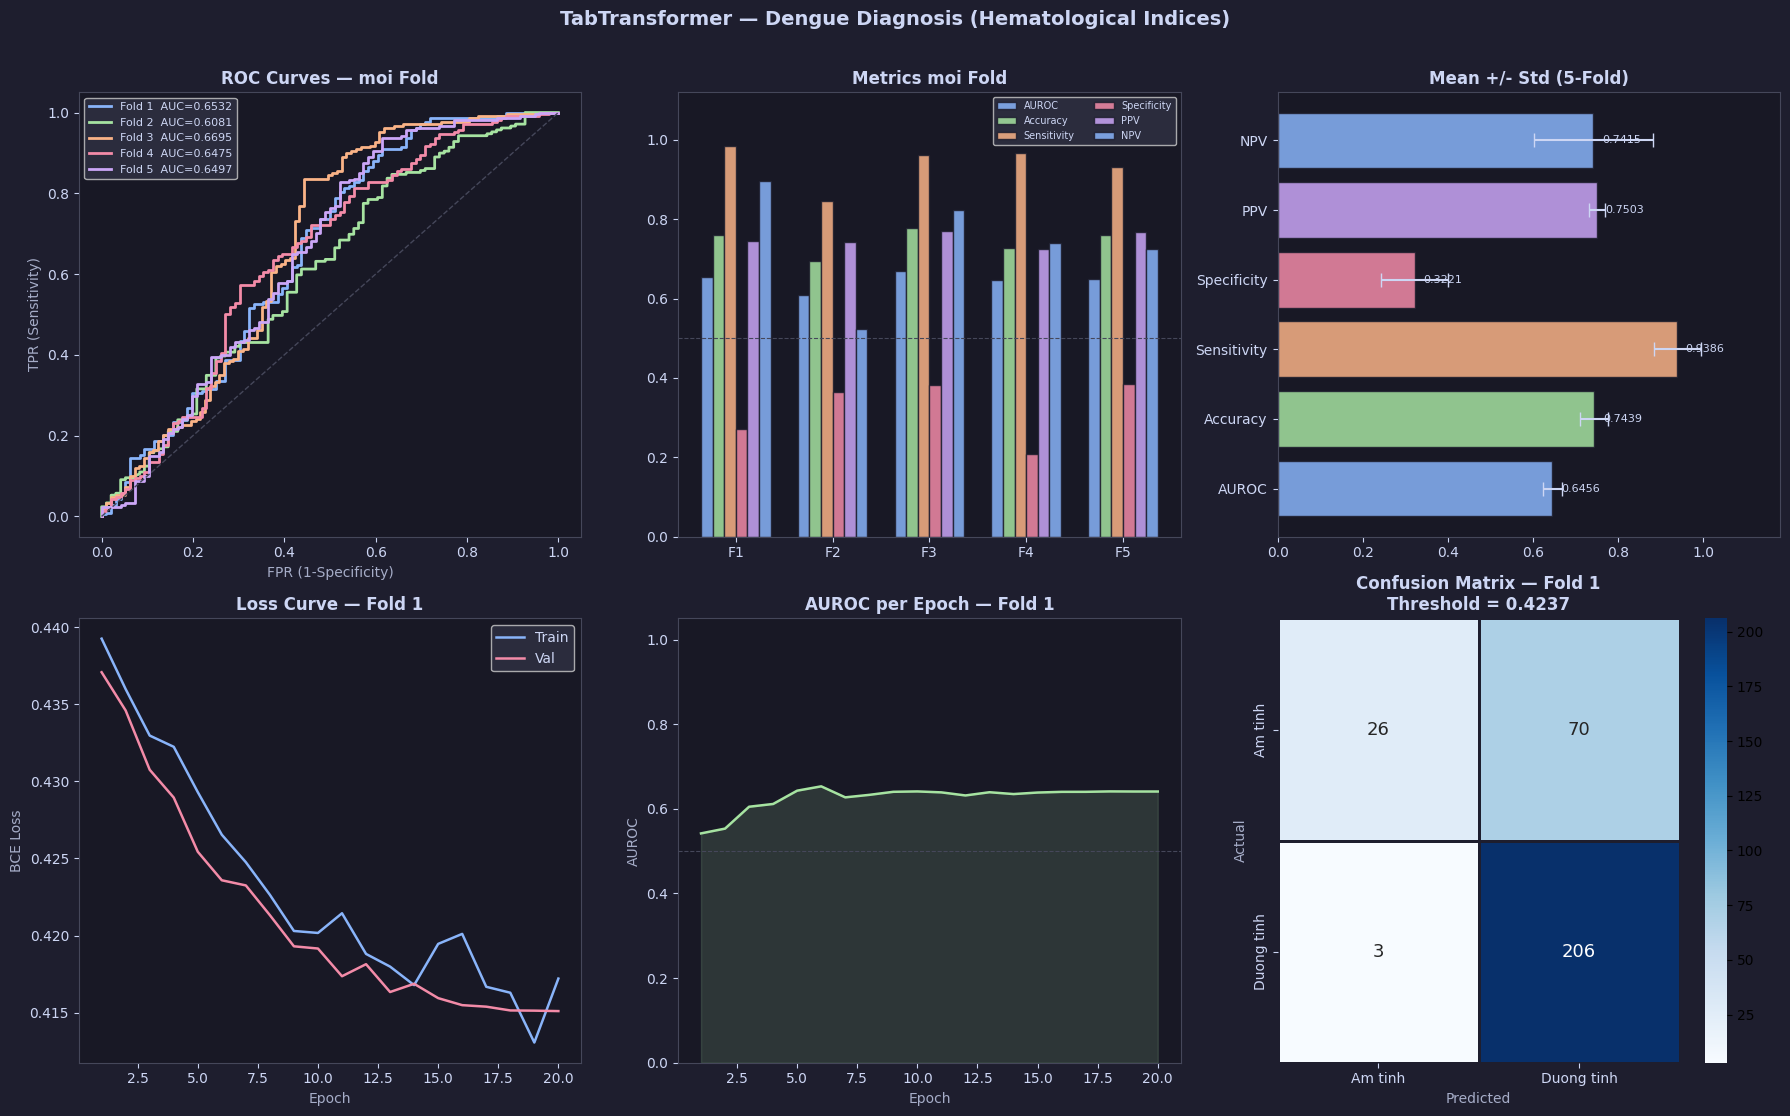

results_overview.png da luu


In [10]:
DARK  = "#1e1e2e"
PANEL = "#181825"
BDR   = "#45475a"
TEXT  = "#cdd6f4"
MUTED = "#a6adc8"
PAL   = ["#89b4fa","#a6e3a1","#fab387","#f38ba8","#cba6f7"]
BM    = ["AUROC","Accuracy","Sensitivity","Specificity","PPV","NPV"]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.patch.set_facecolor(DARK)
for ax in axes.flat:
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT)
    for sp in ax.spines.values():
        sp.set_edgecolor(BDR)

# 1. ROC curves
ax = axes[0, 0]
ax.set_title("ROC Curves — moi Fold", color=TEXT, fontweight="bold")
for fpr, tpr, auc, fi in roc_data:
    ax.plot(fpr, tpr, color=PAL[fi-1], lw=2,
            label="Fold {}  AUC={:.4f}".format(fi, auc))
ax.plot([0,1],[0,1],"--", color=BDR, lw=1)
ax.set_xlabel("FPR (1-Specificity)", color=MUTED)
ax.set_ylabel("TPR (Sensitivity)",   color=MUTED)
ax.legend(fontsize=8, labelcolor=TEXT, facecolor="#313244")

# 2. Bar metrics per fold
ax = axes[0, 1]
ax.set_title("Metrics moi Fold", color=TEXT, fontweight="bold")
x = np.arange(N_FOLDS)
w = 0.12
for i, metric in enumerate(BM):
    vals = [fold_records[f][metric] for f in range(N_FOLDS)]
    ax.bar(x + i*w, vals, width=w, label=metric,
           color=PAL[i % len(PAL)], alpha=0.85, edgecolor=DARK)
ax.set_xticks(x + w * 2.5)
ax.set_xticklabels(["F{}".format(i+1) for i in range(N_FOLDS)], color=TEXT)
ax.set_ylim(0, 1.12)
ax.axhline(0.5, color=BDR, lw=0.8, ls="--")
ax.legend(fontsize=7, labelcolor=TEXT, facecolor="#313244", ncol=2)

# 3. Mean ± Std horizontal bar
ax    = axes[0, 2]
ax.set_title("Mean +/- Std (5-Fold)", color=TEXT, fontweight="bold")
means = [summary_df.loc[summary_df.Metric==m,"Mean"].values[0] for m in BM]
stds  = [summary_df.loc[summary_df.Metric==m,"Std"].values[0]  for m in BM]
bars  = ax.barh(BM, means, xerr=stds, color=PAL[:len(BM)],
                align="center", alpha=0.85,
                capsize=5, ecolor=TEXT, edgecolor=DARK)
ax.set_xlim(0, 1.18)
ax.tick_params(axis="y", labelcolor=TEXT)
for bar, val in zip(bars, means):
    ax.text(val+0.02, bar.get_y()+bar.get_height()/2,
            "{:.4f}".format(val), va="center", color=TEXT, fontsize=8)

# 4. Loss curve Fold 1
ax  = axes[1, 0]
h   = fold_records[0]["history"]
eps = range(1, len(h["tr_loss"]) + 1)
ax.set_title("Loss Curve — Fold 1", color=TEXT, fontweight="bold")
ax.plot(eps, h["tr_loss"],  color="#89b4fa", lw=1.8, label="Train")
ax.plot(eps, h["val_loss"], color="#f38ba8", lw=1.8, label="Val")
ax.set_xlabel("Epoch", color=MUTED)
ax.set_ylabel("BCE Loss", color=MUTED)
ax.legend(labelcolor=TEXT, facecolor="#313244")

# 5. AUROC per epoch Fold 1
ax = axes[1, 1]
ax.set_title("AUROC per Epoch — Fold 1", color=TEXT, fontweight="bold")
ax.plot(eps, h["auroc"], color="#a6e3a1", lw=1.8)
ax.fill_between(eps, h["auroc"], alpha=0.15, color="#a6e3a1")
ax.axhline(0.5, color=BDR, lw=0.8, ls="--")
ax.set_ylim(0, 1.05)
ax.set_xlabel("Epoch", color=MUTED)
ax.set_ylabel("AUROC",  color=MUTED)

# 6. Confusion matrix Fold 1
ax = axes[1, 2]
r0 = fold_records[0]
ax.set_title(
    "Confusion Matrix — Fold 1\nThreshold = {:.4f}".format(r0["Threshold"]),
    color=TEXT, fontweight="bold",
)
cm_arr = np.array([[r0["TN"], r0["FP"]], [r0["FN"], r0["TP"]]])
sns.heatmap(cm_arr, annot=True, fmt="d", ax=ax, cmap="Blues",
            xticklabels=["Am tinh","Duong tinh"],
            yticklabels=["Am tinh","Duong tinh"],
            linewidths=1, linecolor=DARK, annot_kws={"size":13})
ax.set_xlabel("Predicted", color=MUTED)
ax.set_ylabel("Actual",    color=MUTED)
ax.tick_params(colors=TEXT)

plt.suptitle(
    "TabTransformer — Dengue Diagnosis (Hematological Indices)",
    fontsize=14, color=TEXT, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig("results_overview.png", dpi=150,
            bbox_inches="tight", facecolor=DARK)
plt.show()
print("results_overview.png da luu")

In [11]:
categorical_cols = []
numerical_cols = [
    "Monocytes", "RDW-CV", "RBC", "Neutrophils", "Total WBC count",
    "Eosinophils", "Lymphocytes", "MCHC", "MPV", "Age",
    "HCT", "MCV",
]

#Validation
all_selected = categorical_cols + numerical_cols
assert len(all_selected) > 0, "Chua chon feature nao!"

missing = [c for c in all_selected if c not in df.columns]
if missing:
    raise ValueError("Cac cot khong ton tai trong CSV: " + str(missing))

CAT_COLS = categorical_cols
NUM_COLS = numerical_cols

print("Categorical (" + str(len(CAT_COLS)) + "):", CAT_COLS if CAT_COLS else "(khong co)")
print("Numerical   (" + str(len(NUM_COLS)) + "):", NUM_COLS)
print()

print(df[all_selected].describe().round(3).to_string())

Categorical (0): (khong co)
Numerical   (12): ['Monocytes', 'RDW-CV', 'RBC', 'Neutrophils', 'Total WBC count', 'Eosinophils', 'Lymphocytes', 'MCHC', 'MPV', 'Age', 'HCT', 'MCV']

       Monocytes    RDW-CV       RBC  Neutrophils  Total WBC count  Eosinophils  Lymphocytes      MCHC       MPV       Age       HCT       MCV
count   1523.000  1523.000  1523.000     1523.000         1523.000     1523.000     1523.000  1523.000  1523.000  1523.000  1523.000  1523.000
mean       3.271    13.636     4.766       44.485         5483.025        3.083       43.559    32.050     9.589    40.311    45.189    89.816
std        1.210     1.431     0.723        4.345         1137.344        1.001        4.973     1.552     0.849    15.286     3.566     5.516
min        2.000    11.000     4.000       29.000         3500.000        1.000       29.000    27.080     7.500     5.000    36.300    80.000
25%        2.000    12.400     4.000       42.000         4626.000        2.000       41.000    30.900     